In questo esercizio si fa una stima bayesiana dei parametri cosmologici H0 e omch2, ovvero, invece di cercare soltanto i valori migliori, voglio ottenere l’intera distribuzione di probabilità dei parametri, cioè quanto sono probabili certi valori dati i dati osservativi. Il metodo Metropolis-Hastings viene usato per generare campioni da questa distribuzione a posteriori, anche se la formula non si può calcolare in modo analitico. A partire da un punto iniziale, l’algoritmo costruisce una catena di valori che segue la distribuzione desiderata.
NB: H0= costante di Hubble oggi [ km/s/Mpc],  omega_c= frazione dell'univ composta da materia oscura fredda da cui si ottiene omch2= densità di mat.osc.fredda=omega_c*h**2 , con h=H0/100

In [ ]:
import numpy as np  
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm 

In [24]:
!pip install camb

In [25]:
import camb   # Cosmological Arguments for the Microwave Background 
# è un codice usato per calcolare le proprietà cosmologiche dell'universo a partire da cond.iniz. e parametri cosmologici

In [26]:
class LogUniformPrior: 
  """
  Prior uniforme logaritmica : verifica se i parametri sono entro i limiti definiti, altrimenti restituisce -infinito.
  Se i parametri sono entro i limiti, restituisce probabilità uniforme, altrimenti al di fuori probabilità è 0.
  Genera campioni casuali distribuiti uniformemente dentro l'intervallo dei parametri.
  """

  def __init__(self, limits):  # Costruttore
  #limits è un dizionario che def lim inf e sup dei param
    self.limits = limits  # Salva i limiti nei dati interni della classe (self.limits)
    self.parameter_names = list(limits.keys())   # Salva i nomi dei param come lista
    self.n_params = len(limits)  # Salva il num dei param

  def __call__(self, kwargs):  # Metodo che permette di chiamare l'oggetto come una funzione
    #kwargs è un dizionario che contiene i parametri da valutare (chiave,valore)
    # Valuta la prior: se i parametri sono fuori dai limiti,restituisce -infn (cioè zero in scala lin), altrimenti 0
    for key, value in kwargs.items():  
      if kwargs[key] < self.limits[key][0] or kwargs[key] > self.limits[key][1]:
        return -np.inf
    return 0  # Se tutti i parametri sono entro i limiti, restituisce log(1) = 0: prior uniforme

  def generate(self, n_samples): # Metodo per generare campioni casuali secondo la prior
    samples = np.random.uniform(0,1, (self.n_params, n_samples))  # Genera matrice di casuali tra 0 e 1 di dim. (n_param, n_samples)
    for i, (key, value) in enumerate(self.limits.items()): 
      samples[i] = samples[i] * (value[1] - value[0]) + value[0]  # Trasforma i numeri casuali tra 0 e 1 in numeri tra [min, max]
    #-->così ora ho che i numeri sono distributi dentro l'intorno [a,b]
    return samples

In [27]:
def model(params, z_star): # Funzione che calcola i valori teorici cosmologici a partire dai parametri

  camb_params = camb.CAMBparams()  # Inizializza un oggetto CAMBparams per i parametri cosmologici
  camb_params.set_cosmology(**params) # Imposta i parametri cosmologici nell'oggetto CAMBparams
  #**params ="usa ogni chiave-valore come argomento della funzione"
  camb_result = camb.get_background(camb_params)  # Fa partire CAMB con quei parametri e calcola le quantità di background e le salva in camb_result
  rs_star = camb_result.sound_horizon(z_star) # Calcola l'orizzonte acustico alla redshift z_star
  Dm_star = camb_result.angular_diameter_distance(z_star) * (1+z_star)  # Calcola la distanza angolare alla redshift z_star
  
  return rs_star/Dm_star, camb_params.ombh2, camb_params.omch2+camb_params.ombh2 # ombh2=omega_barioni*h**2, come per omch2


In [28]:
class LogLikelihood:  # Classe per calcolare la log-verosimiglianza dei dati cosmologici rispetto al modello
  
  def __init__(self):  
    self.data = [0.01041, 0.02223, 0.14208]  # Valori osservati per rs/Dm, ombh2 e omch2+ombh2
    self.cov = 1.e-9 * np.array( [ [ 0.006621, 0.12444, -1.1929], [0.12444, 21.344, -94.001], [-1.1929, -94.001, 1488.4]])  # Matrice di covarianza dei dati osservati
    self.inv_cov = np.linalg.inv(self.cov) # Inversa della matrice di covarianza per calcolare la verosimiglianza
    self.z_star = 1089 # Redshift a cui sono stati osservati i dati cosmologici, che coincide con l'epoca della decoupling della materia della radiazione 

  def __call__(self, params):  # Metodo che calcola la log-verosimiglianza per un insieme di parametri cosmologici e la rende chiamabile come funzione
      mu_pred = np.array(model(params, self.z_star))  # Chiama la funzione model() per calcolare i valori teorici corrispondenti a quei parametri cosmologici
      diff = self.data-mu_pred # Calcola la differenza tra i dati osservati e i valori teorici predetti
      chi2 = diff @ self.inv_cov @ diff # Calcola il chi-quadro come prodotto scalare tra la differenza e l'inversa della matrice di covarianza
      return -0.5 * chi2 # Loglikelihood= -0.5 * chi2


In [29]:
class MetropolisHastings:

  def __init__(self, log_prior, log_likelihood): 
    self.log_prior = log_prior 
    self.log_likelihood = log_likelihood
    self.parameter_names = self.log_prior.parameter_names 
    self.n_params = self.log_prior.n_params
    self.chain = None
    self.acceptance = None
    self.log_post_chain = None

  def x_to_dict(self, x):
    return {self.parameter_names[i]:x[i] for i in range(len(x))}

  def __call__(self, x0, n_steps, proposal):
    chain = []
    acceptance = [True]
    x0_dict = self.x_to_dict(x0) 
    chain.append(x0) 
    log_post_chain = [self.log_prior(x0_dict) + self.log_likelihood(x0_dict)]

    for i in tqdm(range(n_steps)):
      x_try = proposal(chain[-1]) 
      x_try_dict = self.x_to_dict(x_try)  
      log_post_chain_try = self.log_likelihood(x_try_dict) + self.log_prior(x_try_dict)
      log_ratio = log_post_chain_try - log_post_chain[-1]  
      log_u = np.log(np.random.uniform())

      if log_u < log_ratio: 
        chain.append(x_try)
        log_post_chain.append(log_post_chain_try)
        acceptance.append(True)
      else:
        chain.append(chain[-1])
        log_post_chain.append(log_post_chain[-1])
        acceptance.append(False)

      self.chain = np.array(chain)
      self.acceptance = np.array(acceptance)
      self.log_post_chain = np.array(log_post_chain)


In [30]:
limits = {}  # Definisce i limiti per i parametri cosmologici
limits['H0'] = [60, 75]
limits['omch2'] = [0.11, 0.13]  

log_prior = LogUniformPrior(limits)

params = {}  # Inizializza un dizionario per i parametri cosmologici
params["H0"] = 70 # Valore iniziale di H0
params["omch2"] = 0.12 # Valore iniziale di omch2

print("log prior is:", log_prior(params))  # Verifica il valore della log-prior per i parametri iniziali

log prior is: 0


In [31]:
log_likelihood = LogLikelihood() # Inizializza la classe LogLikelihood per calcolare la log-verosimiglianza
log_likelihood(params) # Calcola la log-verosimiglianza per i parametri iniziali

np.float64(-901.6563641433011)

In [32]:
def proposal(x, loc=[0.1, 0.0005]):  
  """
  Funzione di proposta per il campionamento MCMC: genera un nuovo punto vicino al punto corrente x.
  x: punto corrente
  loc: deviazione standard per ogni parametro, che controlla quanto il nuovo punto si discosta dal corrente.
  """
  return np.random.normal(x, loc)  # # Genera un nuovo punto come una perturbazione gaussiana del punto corrente x

mcmc = MetropolisHastings(log_prior, log_likelihood) # Inizializza l'algoritmo Metropolis-Hastings con la log-prior e la log-likelihood
mcmc([65, 0.12], 10000, proposal) # Esegue l'algoritmo MCMC a partire dal punto iniziale [H0=65, omch2=0.12] per 10000 iterazioni

  0%|          | 0/10000 [00:00<?, ?it/s]

In [33]:
sum(mcmc.acceptance), len(mcmc.acceptance)  # Calcola il numero di accettazioni e il numero totale di passi

(np.int64(3926), 10001)

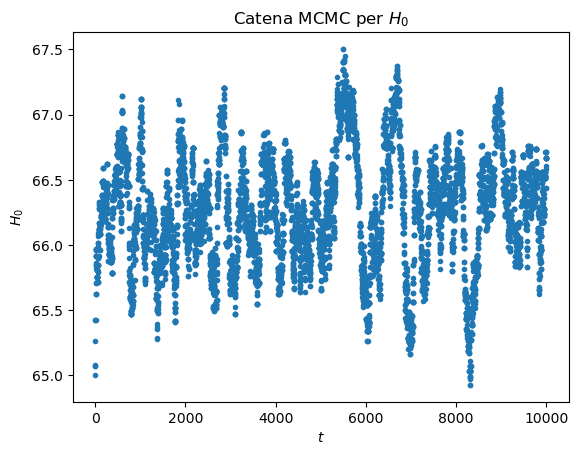

In [34]:
plt.plot(mcmc.chain[:,0],".")  # Traccia la catena MCMC per il parametro H0
plt.ylabel(r"$H_0$")
plt.xlabel(r"$t$") # Indice del passo MCMC
plt.title("Catena MCMC per $H_0$")  
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2174/444181939.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.title("Catena MCMC per $\omega_c$")


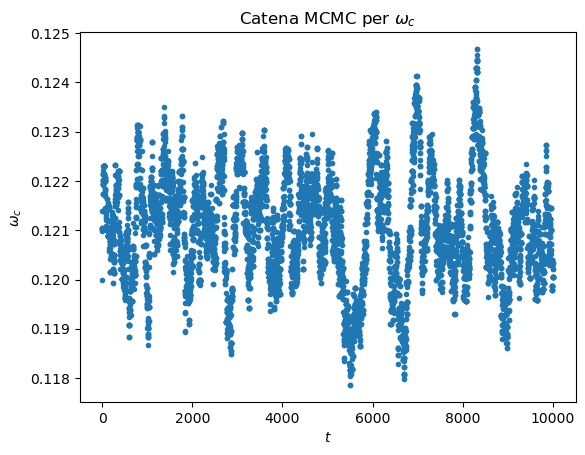

In [35]:
plt.plot(mcmc.chain[:,1],".")  # Traccia la catena MCMC per il parametro omch2
plt.ylabel(r"$\omega_c$")
plt.xlabel(r"$t$")
plt.title("Catena MCMC per $\omega_c$")
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2174/3380615649.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.title("Catena MCMC per $H_0$ e $\omega_c$")


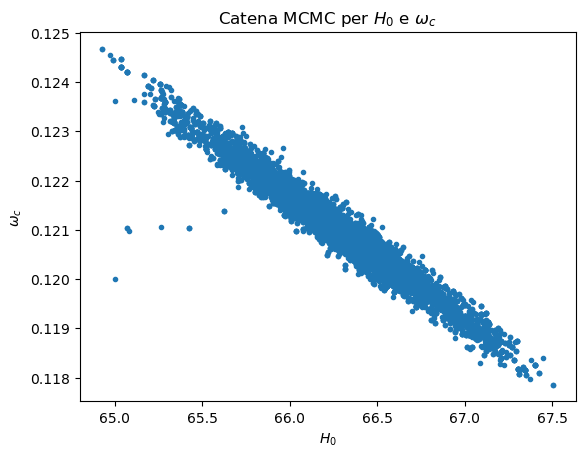

In [36]:
plt.plot(mcmc.chain[:,0], mcmc.chain[:,1], ".")  # Traccia la catena MCMC per i parametri H0 e omch2, quindi mostra la relazione tra i due parametri
plt.xlabel(r"$H_0$")
plt.ylabel(r"$\omega_c$")
plt.title("Catena MCMC per $H_0$ e $\omega_c$")
plt.show()

NB: è un diagramma di dispersione che mostra che i punti si distribuiscono lungia una diagonale discendente, ovvero c'è correlazione negativa tra i due parametri (quando H0 aumenta omegach2 tende a diminuire e sono altamente dipendenti l'uno dall'altro).

NB: a sinistra del grafico osservo il burn-in, ovvero la fase iniziale della catena MCMC in cui l’algoritmo non ha ancora raggiunto la regione di massima probabilità del parametro.

In [37]:
H0_chain = mcmc.chain[:, 0]
omega_c_chain = mcmc.chain[:, 1]

corr_matrix = np.corrcoef(H0_chain, omega_c_chain) # Calcola la matrice di correlazione
correlation = corr_matrix[0, 1] # Estrai il coefficiente di correlazione (fuori diagonale)

print(f"Coefficiente di correlazione tra HH0 e omch2: {correlation:.4f}")

Coefficiente di correlazione tra HH0 e omch2: -0.9799
